# Analysis of Women Safety in Indian Cities Using Machine Learning and Sentiment Analysis

### Objectives
- Analyze public sentiment related to women safety.
- Build a machine learning model for sentiment classification.
- Study crimes against women across Indian states.
- Visualize crime trends and safety insights.

In [12]:
!pip install pandas numpy matplotlib seaborn nltk wordcloud scikit-learn


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


In [14]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Dataset Collection

## Dataset 1: Sentiment140
The Sentiment140 dataset contains tweets labeled as positive and negative sentiments. It is used to train the sentiment analysis model.

## Dataset 2: Crimes Against Women Dataset
This dataset contains state-wise crime statistics related to women, including rape, kidnapping, domestic violence, and other crimes.

In [16]:
from google.colab import files

uploaded = files.upload()

Saving training.1600000.processed.noemoticon.csv to training.1600000.processed.noemoticon (1).csv


In [78]:
import pandas as pd

columns = [
    'sentiment',
    'id',
    'date',
    'query',
    'user',
    'tweet'
]

df = pd.read_csv(
    'training.1600000.processed.noemoticon (1).csv',
    encoding='latin-1',
    names=columns
)

In [18]:
import os

os.listdir()

['.config',
 'training.1600000.processed.noemoticon (1).csv',
 'training.1600000.processed.noemoticon.csv',
 'sample_data']

In [19]:
import os

print(os.path.isfile("training.1600000.processed.noemoticon.csv"))
print(os.path.isfile("training.1600000.processed.noemoticon (1).csv"))

False
True


In [20]:
import pandas as pd

columns = [
    'sentiment',
    'id',
    'date',
    'query',
    'user',
    'tweet'
]

df = pd.read_csv(
    'training.1600000.processed.noemoticon (1).csv',
    encoding='latin-1',
    names=columns
)

In [21]:
df.shape

(1600000, 6)

In [22]:
df.head()

,sentiment,id,date,query,user,tweet
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [23]:
df = df[['sentiment', 'tweet']]

In [24]:
df.head()

,sentiment,tweet
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [25]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Data Preprocessing

The following preprocessing steps were performed:

- Converted text to lowercase
- Removed URLs
- Removed user mentions
- Removed special characters
- Removed stopwords
- Created cleaned tweet text for analysis

In [26]:
def clean_tweet(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove @mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags symbol
    text = re.sub(r'#', '', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = text.strip()

    # Remove stopwords
    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [27]:
print(df['tweet'][0])
print(clean_tweet(df['tweet'][0]))

@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D
thats bummer shoulda got david carr third day


In [28]:
df = df.sample(n=100000, random_state=42)

In [29]:
df['cleaned_tweet'] = df['tweet'].apply(clean_tweet)

In [30]:
df[['tweet', 'cleaned_tweet']].head()

,tweet,cleaned_tweet
541200,@chrishasboobs AHHH I HOPE YOUR OK!!!,ahhh hope ok
750,"@misstoriblack cool , i have no tweet apps fo...",cool tweet apps razr
766711,@TiannaChaos i know just family drama. its la...,know family drama lamehey next time u hang kim...
285055,School email won't open and I have geography ...,school email wont open geography stuff revise ...
705995,upper airways problem,upper airways problem


In [31]:
df[['tweet', 'cleaned_tweet']].head()

,tweet,cleaned_tweet
541200,@chrishasboobs AHHH I HOPE YOUR OK!!!,ahhh hope ok
750,"@misstoriblack cool , i have no tweet apps fo...",cool tweet apps razr
766711,@TiannaChaos i know just family drama. its la...,know family drama lamehey next time u hang kim...
285055,School email won't open and I have geography ...,school email wont open geography stuff revise ...
705995,upper airways problem,upper airways problem


In [32]:
df['sentiment'] = df['sentiment'].replace(4, 1)

In [33]:
df['sentiment'].value_counts()

,count
sentiment,
1,50057
0,49943


In [34]:
X = df['cleaned_tweet']
Y = df['sentiment']

# Feature Extraction using TF-IDF

TF-IDF (Term Frequency-Inverse Document Frequency) converts textual data into numerical vectors. These vectors are used as input for machine learning algorithms.

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(X)

In [36]:
X.shape

(100000, 5000)

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [38]:
print(X_train.shape)
print(X_test.shape)

(80000, 5000)
(20000, 5000)


In [39]:
df['sentiment'].value_counts()
X.shape
print(X_train.shape)
print(X_test.shape)

(80000, 5000)
(20000, 5000)


# Model Training

Logistic Regression was used as the classification algorithm. The model was trained on 80% of the dataset and tested on the remaining 20%.

In [40]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, Y_train)

LogisticRegression(max_iter=1000)

In [41]:
Y_pred = model.predict(X_test)

# Model Evaluation

The performance of the model was evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

In [42]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(Y_test, Y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.76095


In [43]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.77      0.74      0.76      9995
           1       0.75      0.78      0.77     10005

    accuracy                           0.76     20000
   macro avg       0.76      0.76      0.76     20000
weighted avg       0.76      0.76      0.76     20000



In [44]:
import pickle

pickle.dump(model, open('sentiment_model.pkl', 'wb'))
pickle.dump(tfidf, open('tfidf_vectorizer.pkl', 'wb'))

In [45]:
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

accuracy = accuracy_score(Y_test, Y_pred)

print("Accuracy:", accuracy)

print(classification_report(Y_test, Y_pred))

Accuracy: 0.76095
              precision    recall  f1-score   support

           0       0.77      0.74      0.76      9995
           1       0.75      0.78      0.77     10005

    accuracy                           0.76     20000
   macro avg       0.76      0.76      0.76     20000
weighted avg       0.76      0.76      0.76     20000



# Women Safety Tweet Analysis

Women safety related tweets were analyzed using the trained sentiment classification model. The model predicts whether the sentiment is positive or negative.

In [46]:
women_safety_tweets = [

# Delhi
"Women feel unsafe travelling alone at night in Delhi",
"Delhi roads are unsafe for women after dark",
"Poor street lighting makes women feel unsafe in Delhi",
"Police presence has improved women's safety in Delhi",
"Harassment cases are increasing in Delhi public transport",
"Women feel more secure due to CCTV cameras in Delhi",
"Delhi metro is becoming safer for women commuters",
"Women often avoid travelling late at night in Delhi",

# Hyderabad
"Police patrolling has improved safety for women in Hyderabad",
"Hyderabad is becoming safer for women commuters",
"Women feel secure using Hyderabad metro services",
"Street surveillance has improved safety in Hyderabad",
"Women can travel comfortably in Hyderabad public transport",
"Some areas of Hyderabad still feel unsafe at night",
"Hyderabad police launched new women safety initiatives",
"Emergency response systems are helping women in Hyderabad",

# Mumbai
"Harassment incidents are increasing in Mumbai buses",
"Mumbai local trains are generally safe for women",
"Women feel unsafe in crowded areas of Mumbai",
"Mumbai police have improved women safety measures",
"Late night travel remains a concern for women in Mumbai",
"Women appreciate dedicated safety helplines in Mumbai",
"Mumbai has better public awareness regarding women safety",
"Certain suburban areas remain unsafe for women",

# Bangalore
"Women can now travel safely in Bangalore metro",
"Bangalore has improved security in public places",
"Women feel comfortable using metro services in Bangalore",
"Traffic and isolated roads create safety concerns in Bangalore",
"Women appreciate safety apps introduced in Bangalore",
"Bangalore police have increased night patrols",
"Some women still report harassment in Bangalore",
"Public transport safety has improved in Bangalore",

# Chennai
"Poor street lighting makes women feel unsafe in Chennai",
"Women feel secure in well-monitored areas of Chennai",
"Chennai police are improving women safety initiatives",
"Public transport is becoming safer for women in Chennai",
"Women report safety concerns in isolated areas of Chennai",
"CCTV surveillance has improved women's safety in Chennai",
"Night travel remains challenging for women in Chennai",

# Kolkata
"Women feel safe using public transport in Kolkata",
"Kolkata has improved street surveillance systems",
"Women appreciate police support in Kolkata",
"Some regions of Kolkata remain unsafe after dark",
"Public awareness campaigns are helping women in Kolkata",
"Women report safer travel experiences in Kolkata",

# General Women Safety Tweets
"Women face stalking issues in public places",
"Security measures have improved significantly for women",
"Many women feel unsafe walking alone at night",
"Safety apps are helping women report incidents quickly",
"Harassment remains a major concern for women",
"Public awareness programs are improving women's safety",
"Women appreciate stronger law enforcement measures",
"Better lighting can improve women's safety",
"Women deserve safer public spaces",
"Community policing helps improve women's safety"
]

In [47]:
women_df = pd.DataFrame({"tweet": women_safety_tweets})

In [48]:
women_df["cleaned_tweet"] = women_df["tweet"].apply(clean_tweet)

In [49]:
women_X = tfidf.transform(women_df["cleaned_tweet"])

In [50]:
women_df["prediction"] = model.predict(women_X)

women_df["prediction"] = women_df["prediction"].map({
    0: "Negative",
    1: "Positive"
})

In [79]:
women_df.head(20)

,tweet,cleaned_tweet,prediction,city
0,Women feel unsafe travelling alone at night in...,women feel unsafe travelling alone night delhi,Negative,Delhi
1,Delhi roads are unsafe for women after dark,delhi roads unsafe women dark,Negative,Delhi
2,Poor street lighting makes women feel unsafe i...,poor street lighting makes women feel unsafe d...,Negative,Delhi
3,Police presence has improved women's safety in...,police presence improved womens safety delhi,Positive,Delhi
4,Harassment cases are increasing in Delhi publi...,harassment cases increasing delhi public trans...,Positive,Delhi
5,Women feel more secure due to CCTV cameras in ...,women feel secure due cctv cameras delhi,Negative,Delhi
6,Delhi metro is becoming safer for women commuters,delhi metro becoming safer women commuters,Negative,Delhi
7,Women often avoid travelling late at night in ...,women often avoid travelling late night delhi,Positive,Delhi
8,Police patrolling has improved safety for wome...,police patrolling improved safety women hyderabad,Positive,Hyderabad
9,Hyderabad is becoming safer for women commuters,hyderabad becoming safer women commuters,Negative,Hyderabad


In [52]:
cities = [
    "Delhi",
    "Hyderabad",
    "Mumbai",
    "Bangalore",
    "Chennai",
    "Kolkata"
]

def extract_city(tweet):

    for city in cities:
        if city.lower() in tweet.lower():
            return city

    return "Unknown"

women_df["city"] = women_df["tweet"].apply(extract_city)

In [53]:
women_df[['tweet','city','prediction']].head(10)

,tweet,city,prediction
0,Women feel unsafe travelling alone at night in...,Delhi,Negative
1,Delhi roads are unsafe for women after dark,Delhi,Negative
2,Poor street lighting makes women feel unsafe i...,Delhi,Negative
3,Police presence has improved women's safety in...,Delhi,Positive
4,Harassment cases are increasing in Delhi publi...,Delhi,Positive
5,Women feel more secure due to CCTV cameras in ...,Delhi,Negative
6,Delhi metro is becoming safer for women commuters,Delhi,Negative
7,Women often avoid travelling late at night in ...,Delhi,Positive
8,Police patrolling has improved safety for wome...,Hyderabad,Positive
9,Hyderabad is becoming safer for women commuters,Hyderabad,Negative


In [54]:
city_stats = women_df.groupby(
    ['city','prediction']
).size().unstack(fill_value=0)

city_stats

prediction,Negative,Positive
city,,
Bangalore,1,7
Chennai,4,3
Delhi,5,3
Hyderabad,2,6
Kolkata,1,5
Mumbai,2,5
Unknown,3,8


In [55]:
city_stats['Safety Score'] = (
    city_stats['Positive'] /
    (city_stats['Positive'] + city_stats['Negative'])
) * 100

city_stats

prediction,Negative,Positive,Safety Score
city,,,
Bangalore,1,7,87.500000
Chennai,4,3,42.857143
Delhi,5,3,37.500000
Hyderabad,2,6,75.000000
Kolkata,1,5,83.333333
Mumbai,2,5,71.428571
Unknown,3,8,72.727273


In [56]:
city_stats = city_stats.sort_values(
    by='Safety Score',
    ascending=False
)

city_stats

prediction,Negative,Positive,Safety Score
city,,,
Bangalore,1,7,87.500000
Kolkata,1,5,83.333333
Hyderabad,2,6,75.000000
Unknown,3,8,72.727273
Mumbai,2,5,71.428571
Chennai,4,3,42.857143
Delhi,5,3,37.500000


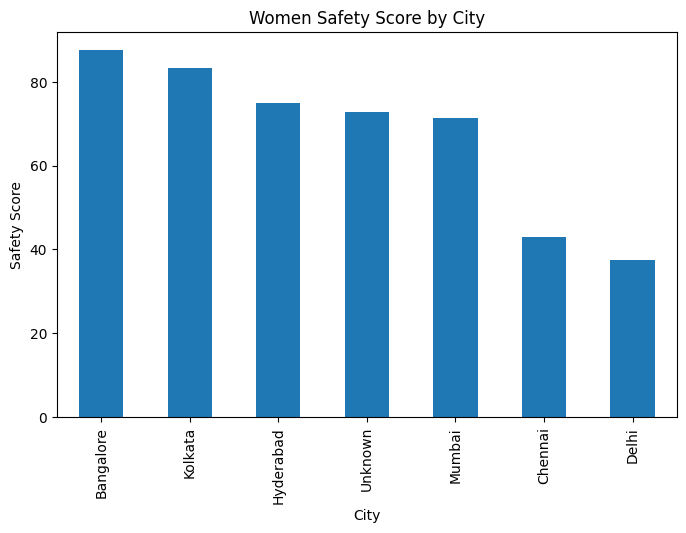

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

city_stats['Safety Score'].plot(kind='bar')

plt.title("Women Safety Score by City")
plt.ylabel("Safety Score")
plt.xlabel("City")

plt.show()

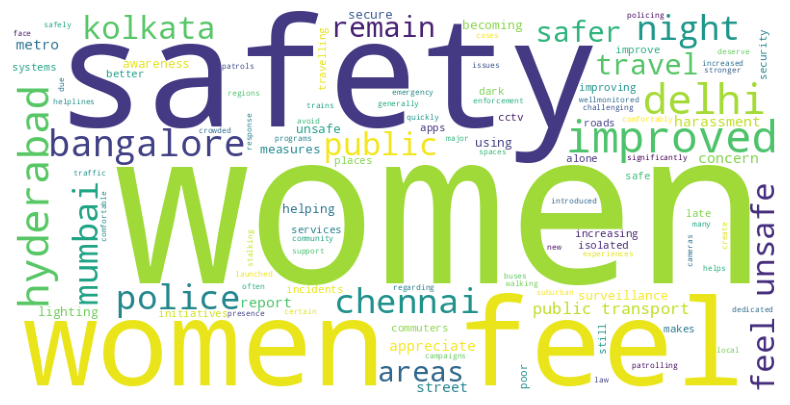

In [58]:
from wordcloud import WordCloud

text = " ".join(women_df['cleaned_tweet'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

# Crime Against Women Dataset Analysis

The crime dataset was analyzed to identify:

- State-wise crime statistics
- Crime trends over years
- States with the highest number of crimes against women

In [59]:
from google.colab import files

uploaded = files.upload()

Saving CrimesOnWomenData.csv to CrimesOnWomenData.csv


In [60]:
import os

os.listdir()

['.config',
 'training.1600000.processed.noemoticon (1).csv',
 'training.1600000.processed.noemoticon.csv',
 'tfidf_vectorizer.pkl',
 'CrimesOnWomenData.csv',
 'sentiment_model.pkl',
 'sample_data']

In [62]:
import pandas as pd

crime_df = pd.read_csv("CrimesOnWomenData.csv")

In [63]:
crime_df.head()

,Unnamed: 0,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT
0,0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7
1,1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0
2,2,ASSAM,2001,817,1070,59,850,4,1248,0
3,3,BIHAR,2001,888,518,859,562,21,1558,83
4,4,CHHATTISGARH,2001,959,171,70,1763,161,840,0


In [64]:
crime_df.columns

Index(['Unnamed: 0', 'State', 'Year', 'Rape', 'K&A', 'DD', 'AoW', 'AoM', 'DV',
       'WT'],
      dtype='object')

In [65]:
import pandas as pd

crime_df = pd.read_csv("CrimesOnWomenData.csv")

crime_df.head()

,Unnamed: 0,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT
0,0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7
1,1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0
2,2,ASSAM,2001,817,1070,59,850,4,1248,0
3,3,BIHAR,2001,888,518,859,562,21,1558,83
4,4,CHHATTISGARH,2001,959,171,70,1763,161,840,0


In [66]:
crime_df.columns

Index(['Unnamed: 0', 'State', 'Year', 'Rape', 'K&A', 'DD', 'AoW', 'AoM', 'DV',
       'WT'],
      dtype='object')

In [67]:
crime_df = crime_df.drop('Unnamed: 0', axis=1)
crime_df.head()

,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT
0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7
1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0
2,ASSAM,2001,817,1070,59,850,4,1248,0
3,BIHAR,2001,888,518,859,562,21,1558,83
4,CHHATTISGARH,2001,959,171,70,1763,161,840,0


In [68]:
crime_df['Total_Crimes'] = (
    crime_df['Rape']
    + crime_df['K&A']
    + crime_df['DD']
    + crime_df['AoW']
    + crime_df['AoM']
    + crime_df['DV']
    + crime_df['WT']
)

In [69]:
crime_df[['State','Year','Total_Crimes']].head()

,State,Year,Total_Crimes
0,ANDHRA PRADESH,2001,13669
1,ARUNACHAL PRADESH,2001,180
2,ASSAM,2001,4048
3,BIHAR,2001,4489
4,CHHATTISGARH,2001,3964


In [70]:
state_crimes = crime_df.groupby('State')['Total_Crimes'].sum()

state_crimes = state_crimes.sort_values(ascending=False)

state_crimes.head(10)

,Total_Crimes
State,
Uttar Pradesh,350934
West Bengal,265807
Madhya Pradesh,262794
Rajasthan,243022
Maharashtra,232095
Assam,223410
Andhra Pradesh,200042
ANDHRA PRADESH,191081
UTTAR PRADESH,178800


In [71]:
state_crimes = crime_df.groupby('State')['Total_Crimes'].sum()

state_crimes = state_crimes.sort_values(ascending=False)

state_crimes.head(10)

,Total_Crimes
State,
Uttar Pradesh,350934
West Bengal,265807
Madhya Pradesh,262794
Rajasthan,243022
Maharashtra,232095
Assam,223410
Andhra Pradesh,200042
ANDHRA PRADESH,191081
UTTAR PRADESH,178800


# Results and Visualizations

The following visualizations were generated:

- Word Cloud
- Confusion Matrix
- Top 10 States with Highest Crimes Against Women
- Crimes Against Women Over Years

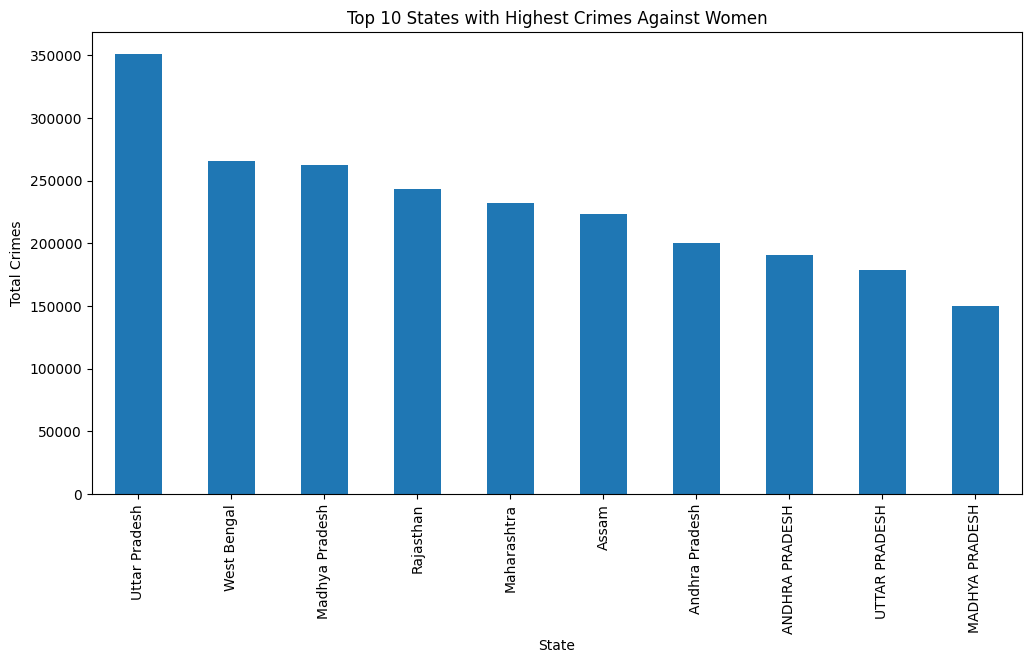

In [72]:
import matplotlib.pyplot as plt

top10 = state_crimes.head(10)

plt.figure(figsize=(12,6))

top10.plot(kind='bar')

plt.title('Top 10 States with Highest Crimes Against Women')

plt.ylabel('Total Crimes')

plt.show()

In [73]:
yearly_crimes = crime_df.groupby('Year')['Total_Crimes'].sum()

yearly_crimes

,Total_Crimes
Year,
2001,128537
2002,128972
2003,128142
2004,140072
2005,139333
2006,149742
2007,170196
2008,182757
2009,190617


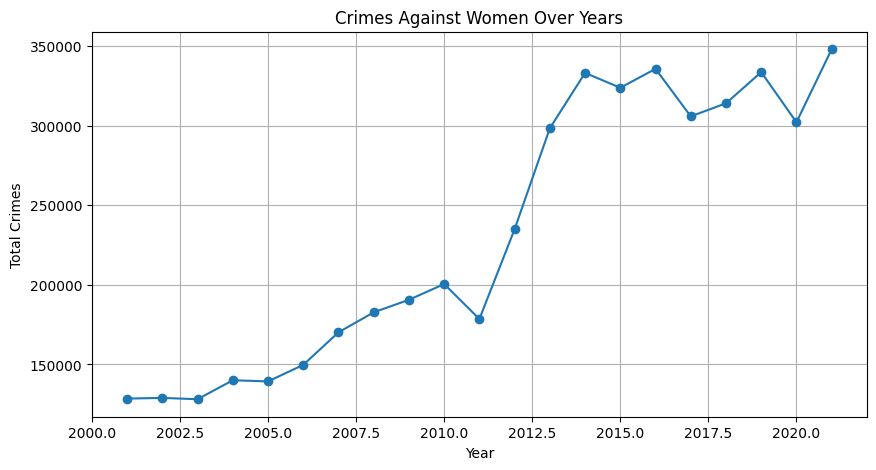

In [74]:
plt.figure(figsize=(10,5))

yearly_crimes.plot(marker='o')

plt.title('Crimes Against Women Over Years')

plt.ylabel('Total Crimes')

plt.grid(True)

plt.show()

In [75]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X = crime_df[['Year']]
y = crime_df['Total_Crimes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

predictions = rf.predict(X_test)

In [76]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 6255.592637674944


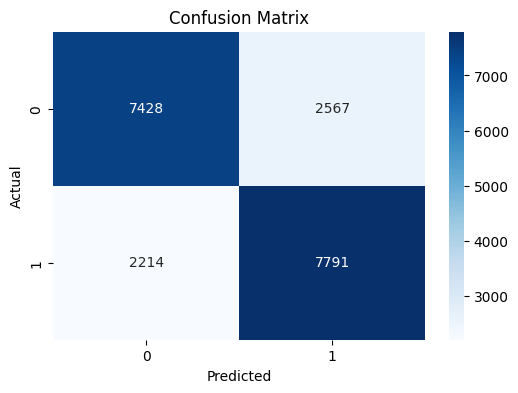

In [80]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Conclusion

A machine learning-based sentiment analysis model was developed using the Sentiment140 dataset. Logistic Regression achieved an accuracy of 76.1%.

Crime analysis revealed increasing trends in crimes against women over the years. Uttar Pradesh recorded the highest cumulative number of crimes against women in the dataset.

The project demonstrates how machine learning and data analytics can be used to understand women safety issues and support decision-making.